# Policy Position Curves: Curriculum vs Reverse Curriculum (Final)

This notebook plots **dataset-level policy-position curves** for `curriculum` and `reverse_curriculum`
from `random_vs_uncertainty_final` using **hierarchical bootstrap**.

For each position index `i`, the y-value is built from:
1. per-permutation metric at position `i`,
2. averaged within subset over permutations,
3. hierarchical bootstrap over subsets within task, then across tasks.


In [1]:
from __future__ import annotations

import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FormatStrFormatter, MaxNLocator, MultipleLocator

REPO_ROOT = Path('/data/ddmg/mvseg-ordering').resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from experiments.analysis.planb_utils import load_planb_summaries
from experiments.analysis.hierarchical_ci import (
    compute_subset_scores,
    hierarchical_bootstrap_task_estimates,
    dataset_bootstrap_stats,
)


In [2]:
# -----------------------------
# Config
# -----------------------------
PROCEDURE = 'random_vs_uncertainty_final'
ABLATION = 'pretrained_baseline5p'
METRICS = ['initial_dice', 'final_dice', 'iterations_used']

METRIC_DISPLAY = {
    'initial_dice': 'Initial Dice Score',
    'final_dice': 'Final Dice Score',
    'iterations_used': 'Interactions Used',
}

POLICIES = ['curriculum', 'reverse_curriculum', 'random']
POLICY_LABELS = {
    'curriculum': 'Hard → Easy',
    'reverse_curriculum': 'Easy → Hard',
    'random': 'Random',
}

# Optional subset of families for plotting order. Set to None for all available.
# PLOT_FAMILIES = ['BTCV', 'T1mix', 'WBC']
PLOT_FAMILIES = None
FAMILY_DISPLAY = {'T1mix': 'COBRE'}
N_COLS = 3
Y_LIM = None  # e.g. (0.4, 0.9)

N_BOOT = 2000
SEED = 23
ALPHA = 0.05

SAVE_FIG = False
FIG_DIR = REPO_ROOT / 'figures' / 'policy_position_curves_final'

from experiments.analysis.notebook_plot_style import (
    FONT_SIZE_SUPTITLE,
    FONT_SIZE_PANEL_TITLE,
    FONT_SIZE_XLABEL,
    FONT_SIZE_YLABEL,
    FONT_SIZE_XTICKS,
    FONT_SIZE_YTICKS,
    FONT_SIZE_LEGEND,
    SUBPLOT_LEFT,
    SUBPLOT_RIGHT,
    SUBPLOT_TOP,
    SUBPLOT_BOTTOM,
    SUBPLOT_WSPACE,
    SUBPLOT_HSPACE,
    LEGEND_Y,
    Y_TICK_STEP_DICE,
    Y_TICK_STEP_ITERS,
    Y_TICK_FMT_DICE,
    Y_TICK_FMT_ITERS,
)


In [3]:
def summarize_dataset_position_curves(
    dataset_df: pd.DataFrame,
    *,
    metric: str,
    policies: list[str],
    n_boot: int,
    seed: int,
    alpha: float,
) -> pd.DataFrame:
    rows: list[dict[str, object]] = []

    image_indices = sorted(int(x) for x in dataset_df['image_index'].dropna().unique())
    for policy_name in policies:
        policy_df = dataset_df[dataset_df['policy_name'].astype(str) == str(policy_name)].copy()
        if policy_df.empty:
            continue

        for image_idx in image_indices:
            at_pos = policy_df[policy_df['image_index'] == image_idx].copy()
            if at_pos.empty:
                continue

            # Per-subset mean at this position (mean across permutations).
            subset_scores = compute_subset_scores(
                at_pos,
                metric,
                task_col='task_id',
                policy_col='policy_name',
            )
            if subset_scores.empty:
                continue

            subset_scores_by_task = {
                str(task_id): grp['subset_mean'].to_numpy(dtype=float)
                for task_id, grp in subset_scores.groupby('task_id')
            }
            subset_scores_by_task = {
                k: v for k, v in subset_scores_by_task.items() if v.size > 0
            }
            if not subset_scores_by_task:
                continue

            task_boot = hierarchical_bootstrap_task_estimates(
                subset_scores_by_task,
                n_boot=n_boot,
                seed=seed,
            )
            _, mean, ci_lo, ci_hi = dataset_bootstrap_stats(task_boot, alpha=alpha)

            rows.append(
                {
                    'policy_name': str(policy_name),
                    'policy_label': POLICY_LABELS.get(str(policy_name), str(policy_name)),
                    'image_index': int(image_idx),
                    'mean': float(mean),
                    'ci_lo': float(ci_lo),
                    'ci_hi': float(ci_hi),
                    'n_tasks': int(len(subset_scores_by_task)),
                    'n_subsets': int(subset_scores.shape[0]),
                }
            )

    if not rows:
        return pd.DataFrame()

    out = pd.DataFrame(rows)
    out = out.sort_values(['policy_name', 'image_index']).reset_index(drop=True)
    return out


In [4]:
raw = load_planb_summaries(
    repo_root=REPO_ROOT,
    procedure=PROCEDURE,
    ablation=ABLATION,
    dataset=None,
    filename='subset_support_images_summary.csv',
    allow_root_fallback=True,
)

raw = raw[raw['policy_name'].astype(str).isin(POLICIES)].copy()
if raw.empty:
    raise ValueError(f'No rows found for policies={POLICIES} in procedure={PROCEDURE}, ablation={ABLATION}.')

metrics_to_run = [m for m in METRICS if m in raw.columns]
missing_metrics = [m for m in METRICS if m not in raw.columns]
if not metrics_to_run:
    raise ValueError(f'None of METRICS are available in raw columns. Requested={METRICS}')
if missing_metrics:
    print(f'[warn] Missing metrics skipped: {missing_metrics}')

# Quick check for permutation count at each (task,subset,policy,image_index).
perm_counts = (
    raw.groupby(['family', 'task_id', 'subset_index', 'policy_name', 'image_index'])['permutation_index']
    .nunique()
)
print(
    f'Permutation count per (family,task,subset,policy,image_index): '
    f'min={int(perm_counts.min())}, median={float(perm_counts.median()):.1f}, max={int(perm_counts.max())}'
)

family_summaries_by_metric: dict[str, dict[str, pd.DataFrame]] = {}
for metric_idx, metric in enumerate(metrics_to_run):
    family_summaries: dict[str, pd.DataFrame] = {}

    for family, fam_df in raw.groupby('family'):
        summary = summarize_dataset_position_curves(
            fam_df,
            metric=metric,
            policies=POLICIES,
            n_boot=N_BOOT,
            seed=SEED + metric_idx * 1000,
            alpha=ALPHA,
        )
        if summary.empty:
            continue
        family_summaries[str(family)] = summary

    if family_summaries:
        family_summaries_by_metric[metric] = family_summaries

if not family_summaries_by_metric:
    raise ValueError('No dataset summaries were produced for any metric.')

print('Metrics prepared:', sorted(family_summaries_by_metric.keys()))
for metric, fam_map in family_summaries_by_metric.items():
    print(f'  {metric}: datasets={sorted(fam_map.keys())}')


Permutation count per (family,task,subset,policy,image_index): min=10, median=10.0, max=100
Metrics prepared: ['final_dice', 'initial_dice', 'iterations_used']
  initial_dice: datasets=['ACDC', 'BTCV', 'BUID', 'DRIVE', 'HipXRay', 'PanDental', 'SCD', 'SCR', 'T1mix', 'TotalSegmentator', 'WBC']
  final_dice: datasets=['ACDC', 'BTCV', 'BUID', 'DRIVE', 'HipXRay', 'PanDental', 'SCD', 'SCR', 'T1mix', 'TotalSegmentator', 'WBC']
  iterations_used: datasets=['ACDC', 'BTCV', 'BUID', 'DRIVE', 'HipXRay', 'PanDental', 'SCD', 'SCR', 'T1mix', 'TotalSegmentator', 'WBC']


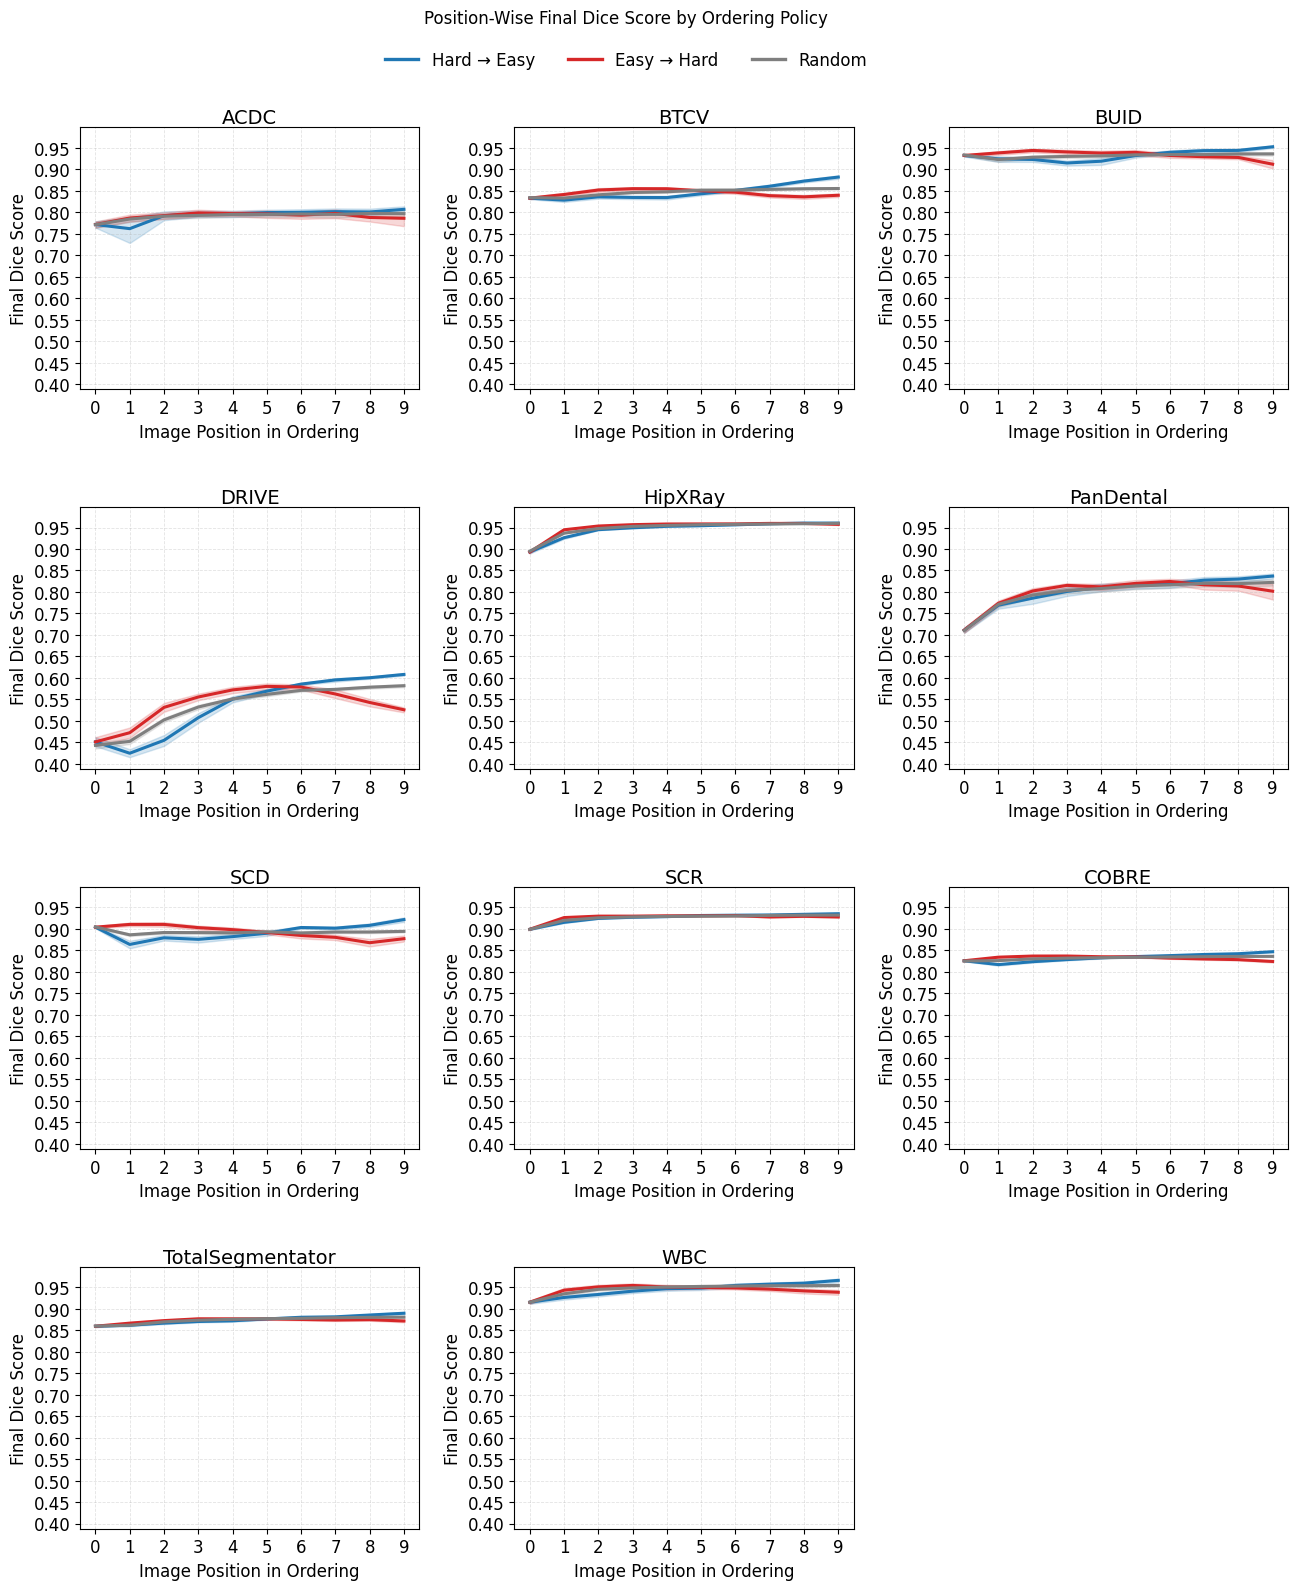

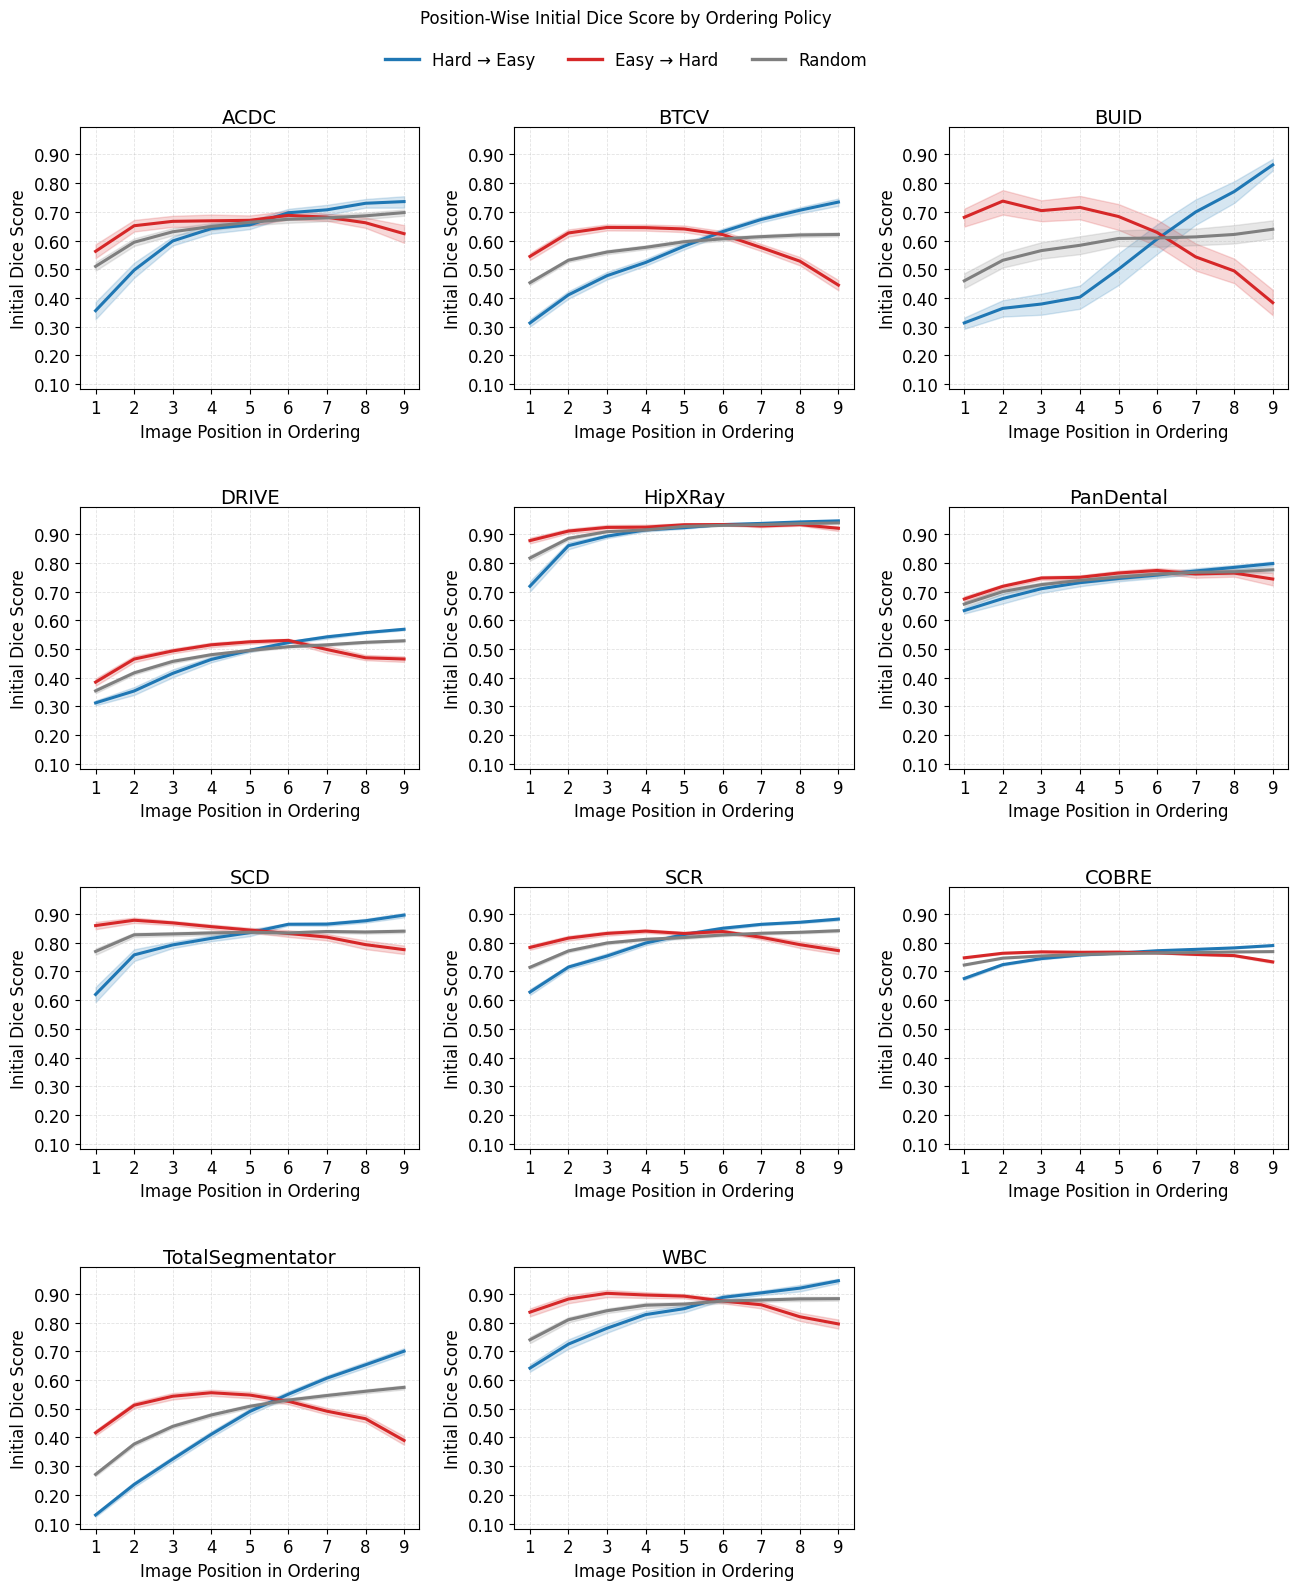

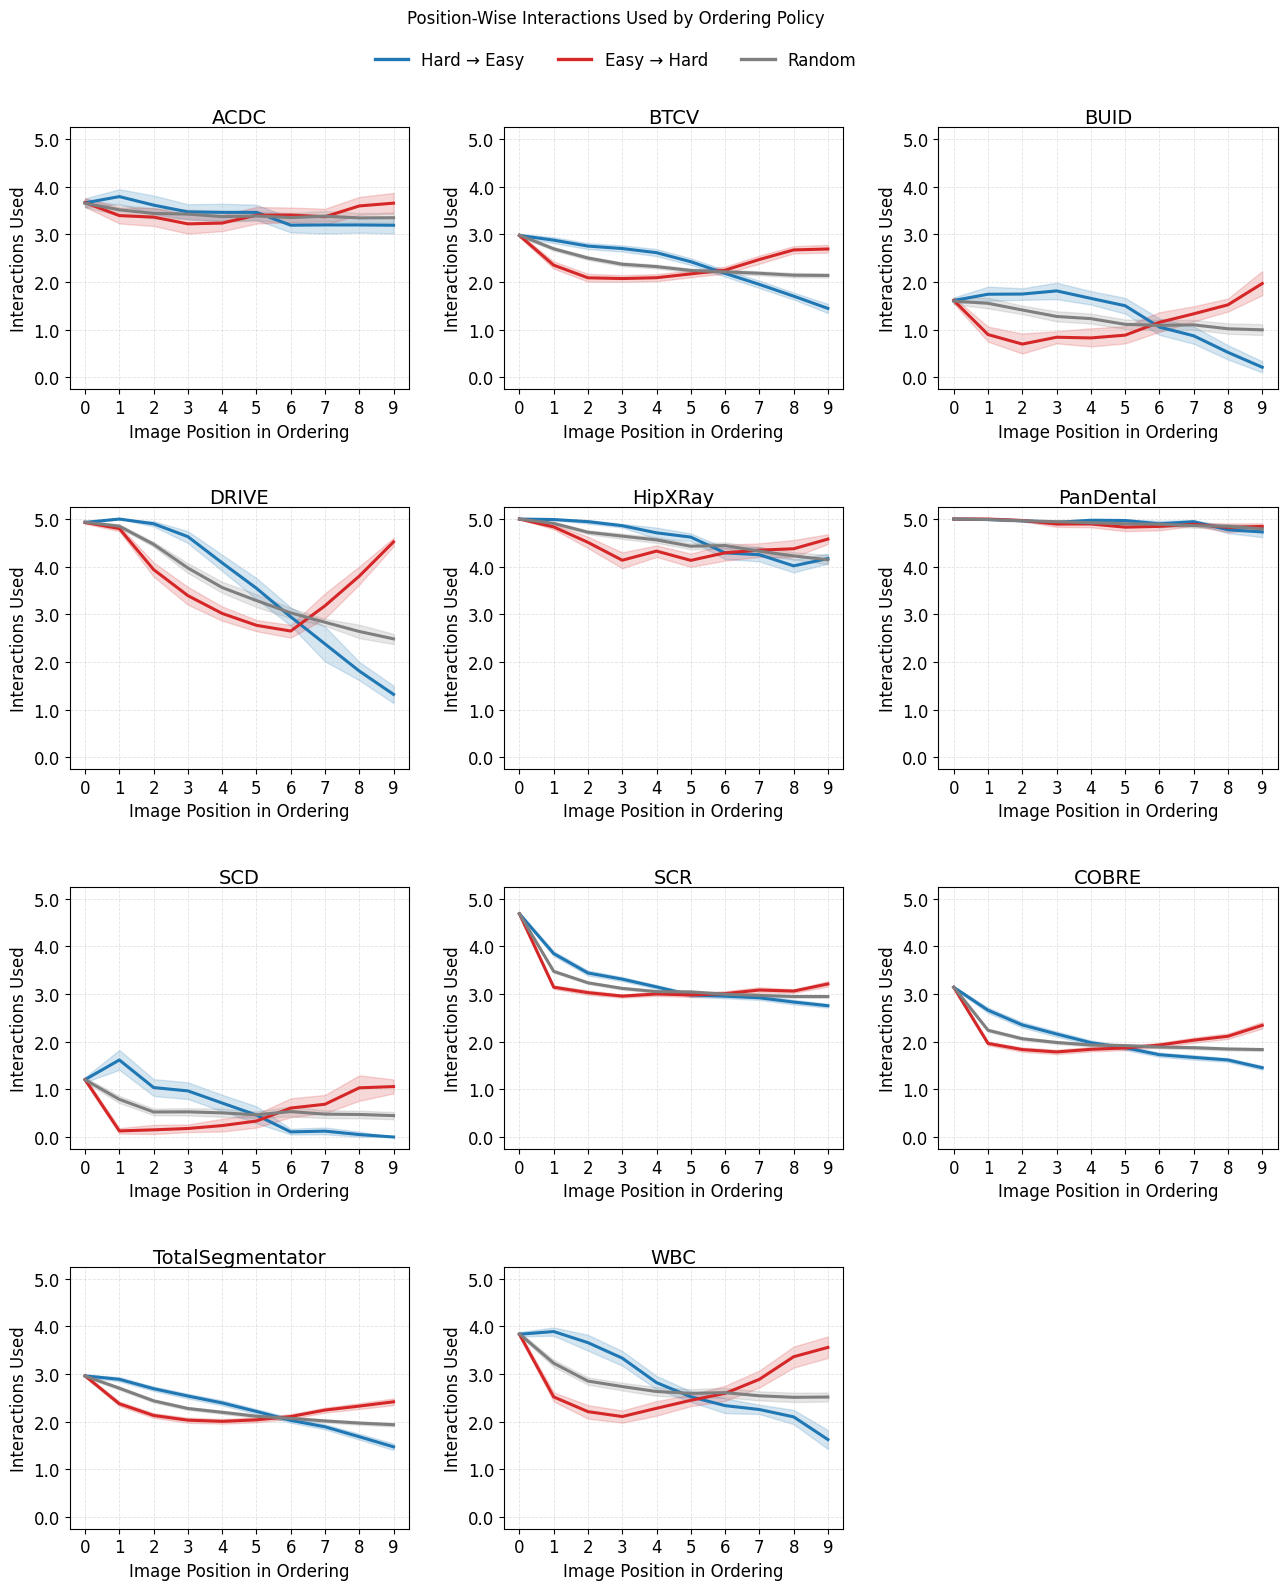

In [5]:
color_map = {
    'curriculum': '#1f77b4',          # blue
    'reverse_curriculum': '#d62728',  # red
    'random': '#7f7f7f',              # gray
}

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color=color_map[p], linewidth=2.4, label=POLICY_LABELS.get(p, p))
    for p in POLICIES
    if p in color_map
]

for metric in sorted(family_summaries_by_metric.keys()):
    family_summaries = family_summaries_by_metric[metric]
    if PLOT_FAMILIES is None:
        families = sorted(family_summaries.keys())
    else:
        families = [f for f in PLOT_FAMILIES if f in family_summaries]

    if not families:
        print(f'[skip] No families to plot for metric={metric}')
        continue

    n_families = len(families)
    n_cols = int(max(1, N_COLS))
    n_rows = int(math.ceil(n_families / n_cols))
    # n_rows = 1
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4.55 * n_cols, 4.55 * n_rows),
        squeeze=False,
        sharey=True,
    )
    axes_flat = axes.ravel()

    metric_label = METRIC_DISPLAY.get(metric, metric.replace('_', ' ').title())
    if metric in {'initial_dice', }:
        step = Y_TICK_STEP_DICE
        tick_fmt = Y_TICK_FMT_DICE
    elif metric == 'final_dice':
        step = 0.05
        tick_fmt = Y_TICK_FMT_DICE
    else:
        step = Y_TICK_STEP_ITERS
        tick_fmt = Y_TICK_FMT_ITERS

    for i, family in enumerate(families):
        ax = axes_flat[i]
        summary = family_summaries[family]

        for policy_name in POLICIES:
            sub = summary[summary['policy_name'] == policy_name].sort_values('image_index')
            if metric == 'initial_dice':
                sub = sub[sub['image_index'] > 0]
            if sub.empty:
                continue

            x = sub['image_index'].to_numpy(dtype=float)
            y = sub['mean'].to_numpy(dtype=float)
            lo = sub['ci_lo'].to_numpy(dtype=float)
            hi = sub['ci_hi'].to_numpy(dtype=float)

            color = color_map.get(policy_name, None)
            label = POLICY_LABELS.get(policy_name, policy_name)

            ax.plot(x, y, color=color, linewidth=2.2, label=label)
            ax.fill_between(x, lo, hi, color=color, alpha=0.18)

        ax.set_title(FAMILY_DISPLAY.get(family, family), fontsize=FONT_SIZE_PANEL_TITLE, pad=2)
        ax.set_xlabel('Image Position in Ordering', fontsize=FONT_SIZE_XLABEL)
        ax.tick_params(axis='y', labelleft=True, labelsize=FONT_SIZE_YTICKS)
        ax.tick_params(axis='x', labelsize=FONT_SIZE_XTICKS)
        ax.set_ylabel(metric_label, fontsize=FONT_SIZE_YLABEL)
        ax.grid(True, linestyle='--', linewidth=0.6, alpha=0.35)
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        if Y_LIM is not None:
            ax.set_ylim(*Y_LIM)
        if step is not None:
            ax.yaxis.set_major_locator(MultipleLocator(step))
            ax.yaxis.set_major_formatter(FormatStrFormatter(tick_fmt))

    fig.suptitle(
        f'Position-Wise {metric_label} by Ordering Policy',
        fontsize=FONT_SIZE_SUPTITLE,
        y=0.995,
    )

    # Hide unused panels.
    for j in range(n_families, len(axes_flat)):
        axes_flat[j].axis('off')

    # Keep clear separation between suptitle, legend, and first row of panel titles.
    subplot_top = 0.82 if n_rows == 1 else 0.93
    legend_y = 0.975 if n_rows == 1 else 0.98

    if legend_handles:
        fig.legend(
            handles=legend_handles,
            loc='upper center',
            bbox_to_anchor=(0.5, legend_y),
            bbox_transform=fig.transFigure,
            ncol=min(3, max(1, len(legend_handles))),
            frameon=False,
            fontsize=FONT_SIZE_LEGEND,
        )

    fig.subplots_adjust(
        left=SUBPLOT_LEFT,
        right=SUBPLOT_RIGHT,
        top=subplot_top,
        bottom=SUBPLOT_BOTTOM,
        wspace=SUBPLOT_WSPACE,
        hspace=SUBPLOT_HSPACE+0.15,
    )

    if SAVE_FIG:
        FIG_DIR.mkdir(parents=True, exist_ok=True)
        out_path = FIG_DIR / f'policy_position_curves_{metric}.png'
        fig.savefig(out_path, dpi=180)
        print(f'saved: {out_path}')

    plt.show()
